# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')



In [2]:
df = pd.read_csv('data/retailmax.csv')
print(f'Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Datos cargados: 200 filas, 5 columnas


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.


count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: Age, dtype: float64


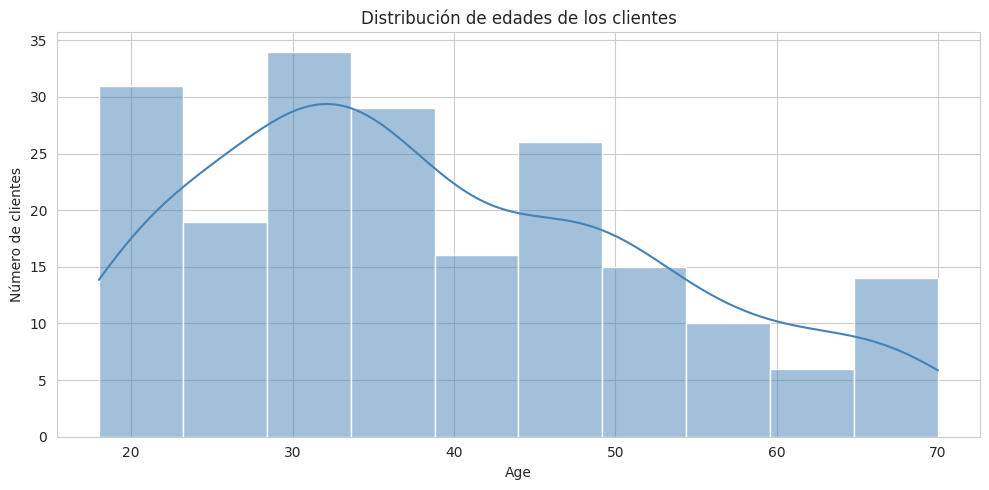

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=10, kde=True, color='steelblue')
plt.title('Distribución de edades de los clientes')
plt.xlabel('Age')
plt.ylabel('Número de clientes')
plt.tight_layout()
print(df['Age'].describe())

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.
- **Nota**: Como la media puede verse afectada por valores atípicos, también se reporta la mediana.


Estadísticas de ingreso por género:
         mean  median    std
Gender                      
Female  59.25    60.0  26.01
Male    62.23    62.5  26.64


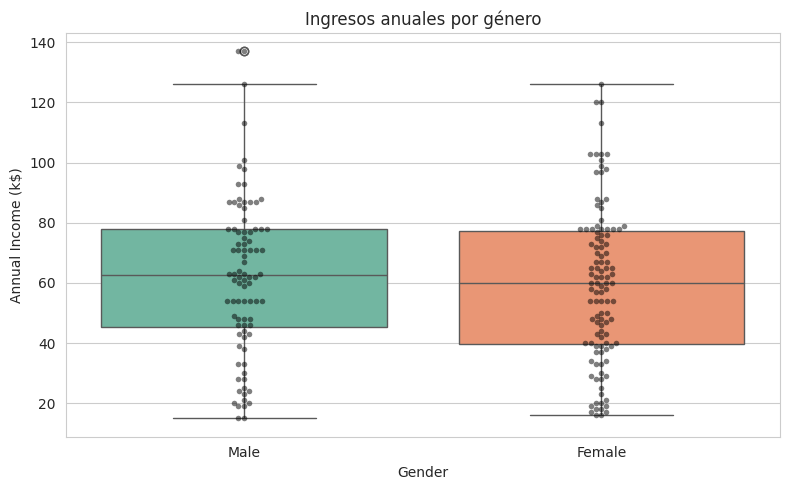

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='Annual Income (k$)', palette='Set2')
sns.swarmplot(data=df, x='Gender', y='Annual Income (k$)', color='k', alpha=0.5, size=4)
plt.title('Ingresos anuales por género')
plt.xlabel('Gender')
plt.ylabel('Annual Income (k$)')
plt.tight_layout()

income_stats = df.groupby('Gender')['Annual Income (k$)'].agg(
    mean='mean',
    median='median',
    std='std'
).round(2)
print('Estadísticas de ingreso por género:')
print(income_stats)

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

Estadísticas de Spending Score por grupo de edad:
           mean  median
AgeGroup               
18-24     56.26    55.0
25-34     63.17    70.0
35-44     49.43    41.0
45-54     36.23    42.0
55-64     32.31    39.0
65+       46.71    49.0


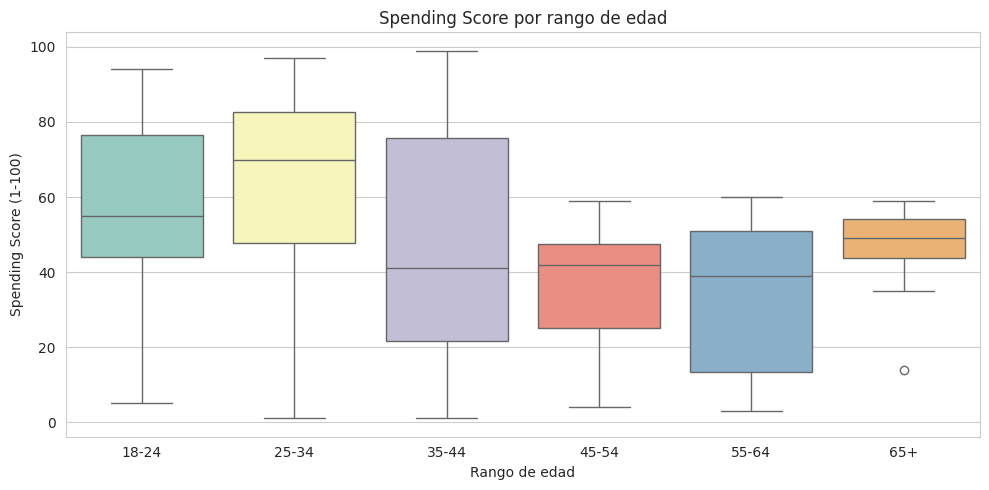

In [5]:
age_bins = [18, 25, 35, 45, 55, 65, 76]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='AgeGroup', y='Spending Score (1-100)', palette='Set3')
plt.title('Spending Score por rango de edad')
plt.xlabel('Rango de edad')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()

agegroup_stats = df.groupby('AgeGroup')['Spending Score (1-100)'].agg(
    mean='mean',
    median='median'
).round(2)
print('Estadísticas de Spending Score por grupo de edad:')
print(agegroup_stats)

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

Coeficiente de correlación de Pearson: 0.01


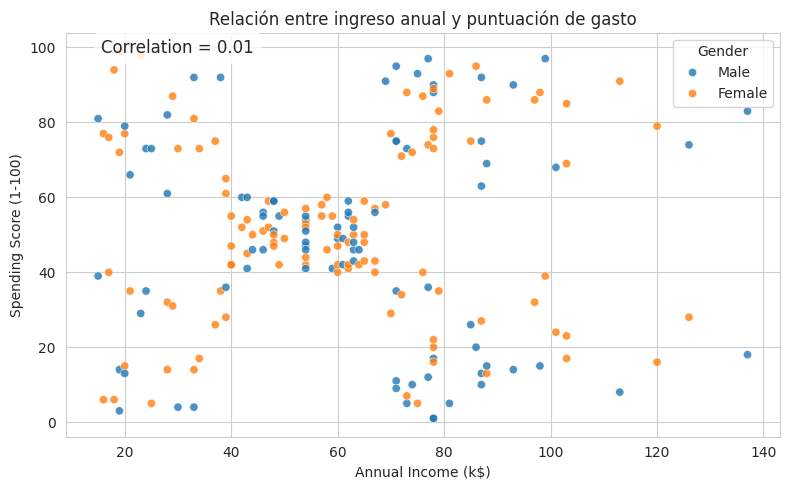

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', alpha=0.8)
plt.title('Relación entre ingreso anual y puntuación de gasto')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender')

corr = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
plt.annotate(
    f'Correlation = {corr:.2f}',
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.8)
)
plt.tight_layout()
print('Coeficiente de correlación de Pearson:', round(corr, 2))

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).
- **Nota**: Aquí la mediana ayuda a entender el comportamiento típico cuando hay valores extremos en el gasto.


Media y mediana por rango de ingreso:
              mean  median
IncomeRange               
0-29         50.40    50.5
30-49        50.00    51.0
50-69        50.15    49.0
70-99        50.60    51.5
100+         48.79    48.0


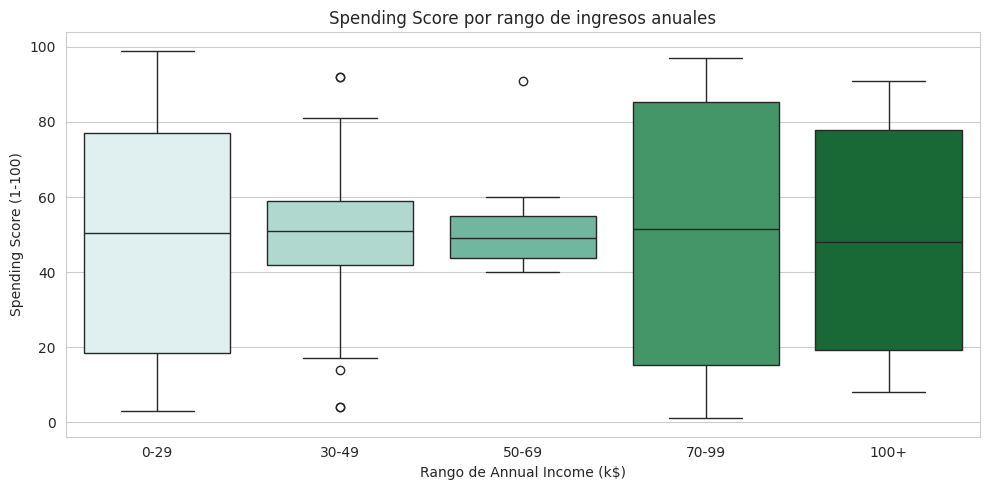

In [7]:
income_bins = [0, 30, 50, 70, 100, 140]
income_labels = ['0-29', '30-49', '50-69', '70-99', '100+']
df['IncomeRange'] = pd.cut(df['Annual Income (k$)'], bins=income_bins, labels=income_labels, right=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='IncomeRange', y='Spending Score (1-100)', palette='BuGn')
plt.title('Spending Score por rango de ingresos anuales')
plt.xlabel('Rango de Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()

income_stats = df.groupby('IncomeRange')['Spending Score (1-100)'].agg(
    mean='mean',
    median='median'
).round(2)
print('Media y mediana por rango de ingreso:')
print(income_stats)

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

Gender
Female    112
Male       88
Name: count, dtype: int64
Gender
Female    56.0
Male      44.0
Name: Porcentaje, dtype: float64


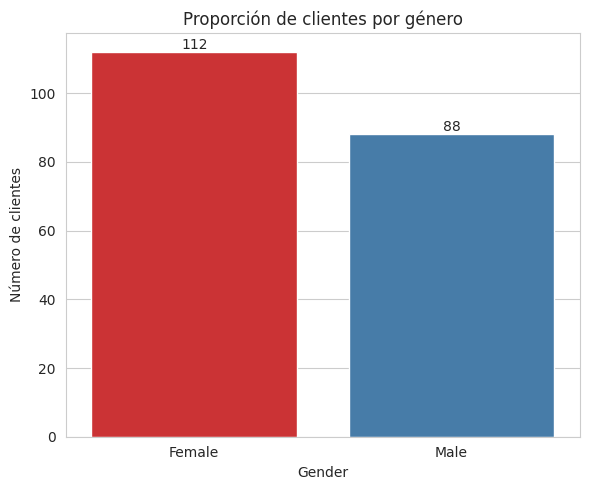

In [8]:
plt.figure(figsize=(6, 5))
gender_counts = df['Gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='Set1')
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 1, str(v), ha='center')
plt.title('Proporción de clientes por género')
plt.xlabel('Gender')
plt.ylabel('Número de clientes')
plt.tight_layout()
print(gender_counts)
print((gender_counts / gender_counts.sum() * 100).round(1).rename('Porcentaje'))

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.
- **Nota**: Se compara la media y la mediana para evaluar si hay sesgo por valores atípicos.


Media y mediana de Spending Score por grupo de edad:
           mean  median
AgeGroup               
18-24     56.26    55.0
25-34     63.17    70.0
35-44     49.43    41.0
45-54     36.23    42.0
55-64     32.31    39.0
65+       46.71    49.0


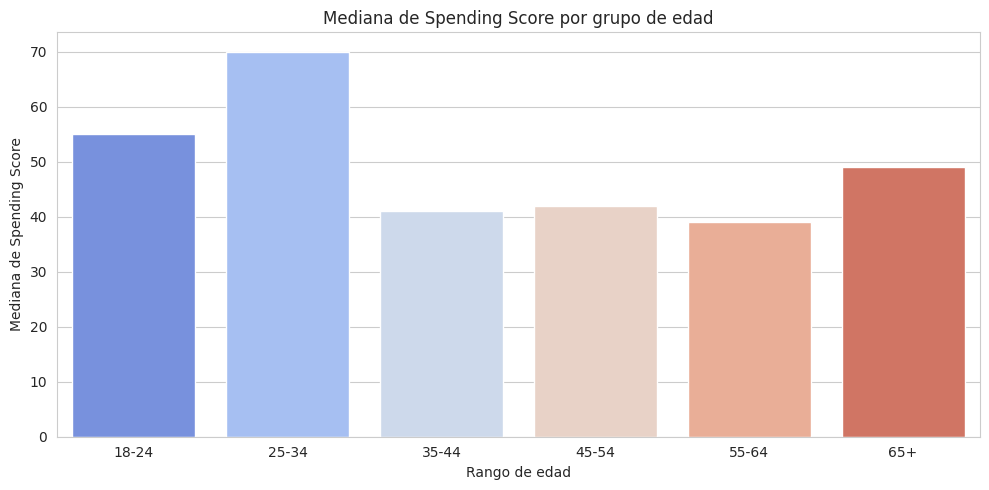

In [9]:
age_group_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
spending_by_age = df.groupby('AgeGroup', observed=True)['Spending Score (1-100)'].agg(
    mean='mean',
    median='median'
).reindex(age_group_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=spending_by_age.index, y=spending_by_age['median'].values, palette='coolwarm')
plt.title('Mediana de Spending Score por grupo de edad')
plt.xlabel('Rango de edad')
plt.ylabel('Mediana de Spending Score')
plt.tight_layout()
print('Media y mediana de Spending Score por grupo de edad:')
print(spending_by_age.round(2))

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

Coeficiente de correlación Age vs Annual Income: -0.01


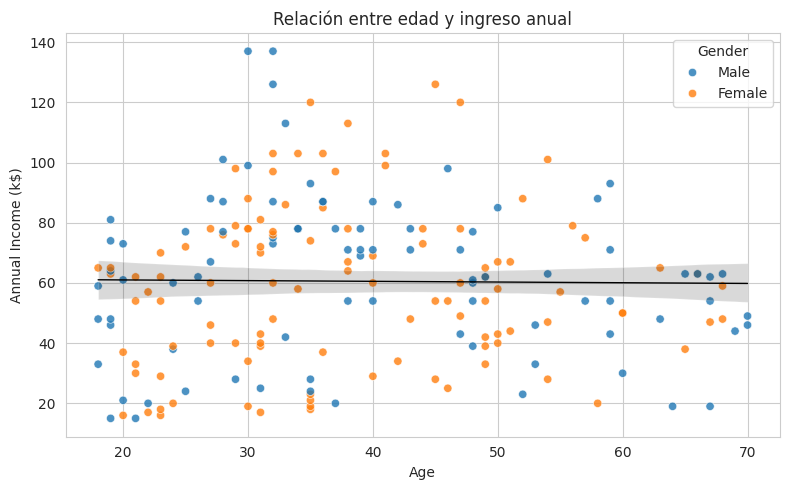

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Annual Income (k$)', hue='Gender', alpha=0.8)
sns.regplot(data=df, x='Age', y='Annual Income (k$)', scatter=False, color='black', line_kws={'linewidth': 1})
plt.title('Relación entre edad y ingreso anual')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.tight_layout()
corr_age_income = df['Age'].corr(df['Annual Income (k$)'])
print('Coeficiente de correlación Age vs Annual Income:', round(corr_age_income, 2))

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

Jointplot de la distribución conjunta generado.


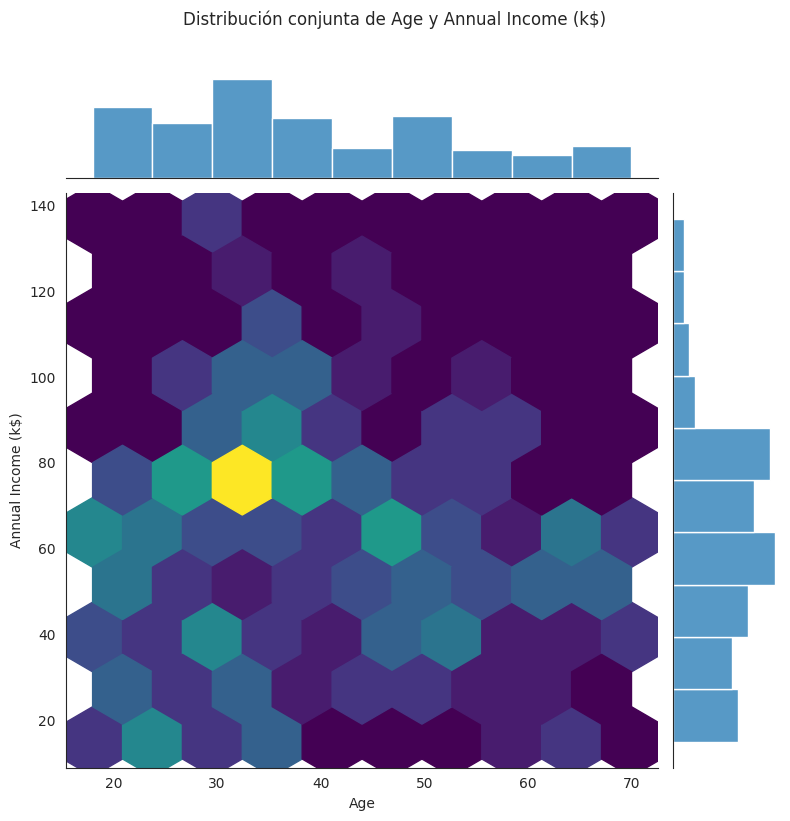

In [11]:
with sns.axes_style('white'):
    g = sns.jointplot(data=df, x='Age', y='Annual Income (k$)', kind='hex', height=8, cmap='viridis')
    g.set_axis_labels('Age', 'Annual Income (k$)')
    plt.suptitle('Distribución conjunta de Age y Annual Income (k$)', y=1.02)
plt.tight_layout()
print('Jointplot de la distribución conjunta generado.')

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

             mean   50%
Gender                 
Female  51.526786  50.0
Male    48.511364  50.0


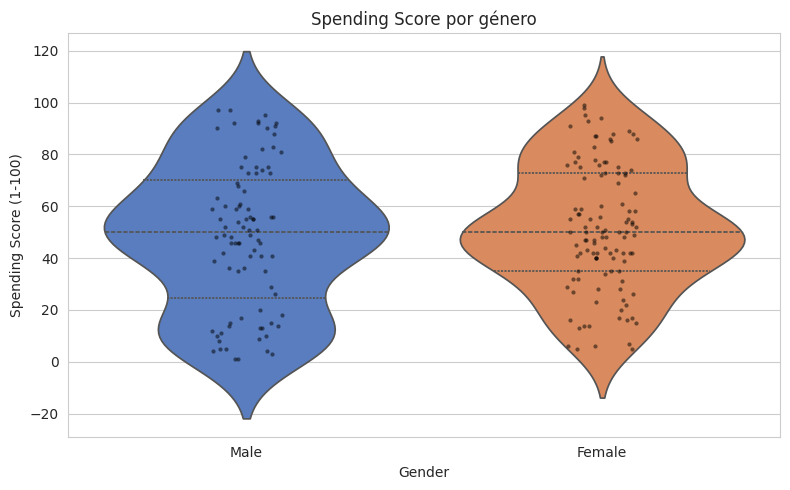

In [12]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Gender', y='Spending Score (1-100)', palette='muted', inner='quartile')
sns.stripplot(data=df, x='Gender', y='Spending Score (1-100)', color='k', alpha=0.5, jitter=True, size=3)
plt.title('Spending Score por género')
plt.xlabel('Gender')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
print(df.groupby('Gender')['Spending Score (1-100)'].describe()[['mean', '50%']])